# Customer Churn Prediction — Feature Engineering

This notebook constructs the customer-level modeling dataset used to train 
the churn prediction model.

The previous EDA stage identified the key behavioral dimensions that 
differentiate churned from active customers:

- **Engagement intensity** — purchase frequency is the strongest churn signal
- **Customer value** — monetary spend strongly differentiates churned and active customers
- **Recency** — time since last purchase provides a natural inactivity signal
- **Early lifecycle behavior** — many customers purchase only once, making 
  first-month activity a meaningful predictor
- **Behavioral consistency** — irregular purchase cadence signals disengagement 
  before full inactivity sets in

These findings directly inform the feature set constructed here. Features are 
generated using a **sliding window framework** to avoid data leakage and 
simulate realistic deployment conditions.

## Notebook structure

| Section | Content |
|---|---|
| 1. Setup | Libraries, data loading |
| 2. Sliding window framework | Configuration and window generation |
| 3. Feature design | Strategy and full feature definitions |
| 4. Feature extraction | Pipeline execution and validation |
| 5. Dataset assembly | Concatenation, quality checks, window statistics |
| 6. Feature stability | Mean and distribution stability across windows |
| 7. Feature-target relationships | Correlation analysis |
| 8. Conclusions and known issues | Summary and limitations |
| 9. Save | Output dataset |

## 1. Setup

The feature engineering pipeline is implemented as a set of modules under 
`src/churn/`. The notebook imports the pipeline entry point 
(`extract_features_for_window`) and configuration constants, keeping 
the notebook focused on orchestration and analysis rather than 
implementation details.

The dataset is filtered to **United Kingdom customers** only, consistent 
with the EDA stage. International customers are excluded to avoid 
confounding effects from shipping differences and irregular purchasing 
patterns.

In [1]:
import sys
from pathlib import Path

# Project root on path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm import tqdm

from src.churn.config import (
    OBSERVATION_WINDOW_DAYS,
    PREDICTION_WINDOW_DAYS,
    WINDOW_STEP_DAYS,
    MIN_CUSTOMER_HISTORY_DAYS,
)
from src.churn.windowing import generate_window_starts
from src.churn.feature_pipeline import extract_features_for_window

# Visualization
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

In [2]:
retail_df = pd.read_parquet('../data/processed/online_retail_cleaned.parquet')
uk_df = retail_df[retail_df['Country'] == 'United Kingdom'].copy()

# Validate required columns are present
required_cols = ['CustomerID', 'InvoiceDate', 'Invoice', 'TotalSum', 'TransactionType']
missing_cols  = [col for col in required_cols if col not in uk_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Dataset summary — UK customers only")
print("-" * 45)
print(f"  Rows:              {len(uk_df):,}")
print(f"  Unique customers:  {uk_df['CustomerID'].nunique():,}")
print(f"  Total invoices:    {uk_df['Invoice'].nunique():,}")
print(f"  Date range:        {uk_df['InvoiceDate'].min().date()} → "
      f"{uk_df['InvoiceDate'].max().date()}")
print()
print("  ✓ All required columns present")

Dataset summary — UK customers only
---------------------------------------------
  Rows:              716,069
  Unique customers:  5,407
  Total invoices:    40,500
  Date range:        2009-12-01 → 2011-12-09

  ✓ All required columns present


## 2. Sliding Window Framework

Features and churn labels are computed over **sliding temporal windows** 
rather than once across the full dataset. This is essential for two reasons:

- **Avoiding data leakage** — features for each customer are computed only 
  from data available before the prediction point, mirroring real deployment
- **Maximizing training data** — sliding windows generate multiple observations 
  per customer at different points in time, increasing dataset size without 
  collecting new data

Each window has two components:
```
|<--- observation window (180 days) --->|<--- prediction window (90 days) --->|
feature_start                      feature_end                           label_end
```

Features are computed from transactions in the **observation window**. 
The **churn label** is determined by whether the customer made any purchase 
in the subsequent prediction window (no purchases means churned).

Windows slide forward in **30-day steps**, so consecutive windows overlap 
by 150 days. Only customers with at least **30 days** of transaction history 
within the observation window are included, ensuring sufficient behavioral 
signal for feature computation.

In [3]:
print("Feature Engineering Configuration")
print("-" * 35)
print(f"Observation window: {OBSERVATION_WINDOW_DAYS} days")
print(f"Prediction window: {PREDICTION_WINDOW_DAYS} days")
print(f"Window step: {WINDOW_STEP_DAYS} days")
print(f"Min customer history: {MIN_CUSTOMER_HISTORY_DAYS} days")

Feature Engineering Configuration
-----------------------------------
Observation window: 180 days
Prediction window: 90 days
Window step: 30 days
Min customer history: 30 days


### 2.1 Window generation

In [4]:
window_starts = generate_window_starts(
    uk_df,
    OBSERVATION_WINDOW_DAYS,
    PREDICTION_WINDOW_DAYS,
    WINDOW_STEP_DAYS,
)

print(f"Windows generated:  {len(window_starts)}")
print(f"First window start: {window_starts[0].date()}")
print(f"Last window start:  {window_starts[-1].date()}")
print()
print(f"Each window covers {OBSERVATION_WINDOW_DAYS} days of features + "
      f"{PREDICTION_WINDOW_DAYS} days of labels")
print(f"Total span per window: "
      f"{OBSERVATION_WINDOW_DAYS + PREDICTION_WINDOW_DAYS} days")

Windows generated:  16
First window start: 2010-05-30
Last window start:  2011-08-23

Each window covers 180 days of features + 90 days of labels
Total span per window: 270 days


## 3. Feature Design

### 3.1 Strategy

Features are designed to capture the behavioral dimensions identified during 
EDA as predictive of churn. The design follows three principles:

**Coverage** — each known churn signal gets at least one feature. The core 
RFM dimensions (Recency, Frequency, Monetary) are the foundation, extended 
with features that capture behavioral dynamics and lifecycle stage.

**Robustness** — where raw features are heavily skewed (Monetary, Frequency), 
log-transformed variants are included to improve model stability. Features 
are expressed as ratios where possible to normalize across customers with 
different activity levels.

**Temporal consistency** — all features are computed within the observation 
window only. No future information leaks into the feature set.

Feature selection was refined iteratively by adding and removing feature 
groups while monitoring model performance (ROC-AUC and top-decile capture). 
Key findings from that process:

- **RFM features** are the primary drivers of model performance
- **`ValueEngagement`** (LogMonetary × EngagementDensity) combines two 
  strong individual signals into a single interaction term. Its correlation 
  with churn is among the highest in the feature set
- **Early lifecycle features** significantly improve identification of 
  one-time and early-churn customers
- **Trend features** (`RevenueTrend`, `RecentShareLog`) were retained 
  after iterative performance evaluation
- **Cyclic encoding** of `FavoriteMonth` (sin/cos) replaced the raw integer 
  to correctly represent the circular nature of calendar months
- **Three features were removed** after inspecting model feature importance: 
  `LogFrequency`, `IsOrderValueCVDefined`, and `IsPurchaseIntervalCVDefined`. 
  These showed negligible importance scores and were dropped. Other features 
  were removed or retained based on observed model performance rather than 
  a formal importance analysis.

**Note**: `Q4Ratio` is included in the feature set but is a **calendar 
artifact** . It is zero for all customers in windows that do not overlap 
October–December, including the test windows. This is verifiable directly 
from the data (see section 8.2) and confirmed by SHAP analysis in the 
modeling notebook. It should be removed and replaced with a rolling 
seasonal activity feature in the next iteration.

### 3.2 Feature definitions

All 23 features generated by the pipeline, grouped by behavioral dimension:

| Feature | Group | Definition | Churn signal |
|---|---|---|---|
| `Recency` | RFM | Days since last purchase | High → higher risk |
| `Frequency` | RFM | Number of purchases | Low → higher risk |
| `Monetary` | RFM | Total spend | Low → higher risk |
| `LogMonetary` | RFM | log1p(Monetary) | Normalized value, reduces right skew |
| `AvgOrderValue` | Order value | Mean transaction value | Low → higher risk |
| `OrderValueCV` | Order value | Spend variability (std/mean) | High → irregular behavior |
| `ReturnRate` | Product | Proportion of purchases returned | High → dissatisfaction signal |
| `UniqueProducts` | Product | Distinct products purchased | Low → narrow engagement |
| `ProductDiversityRate` | Product | UniqueProducts / Frequency | Low → catalog disengagement |
| `FirstMonthPurchases` | Lifecycle | Purchases in first 30 days | Low → weak initial engagement |
| `MonetaryFirstMonth` | Lifecycle | Spend in first 30 days | Low → weak initial value |
| `AvgOrderValueFirstMonth` | Lifecycle | Avg order value in first month | Low → low early commitment |
| `CustomerLifetime` | Lifecycle | Days since first purchase | Short → newer, higher risk |
| `RecentShareLog` | Trend | log1p(recent freq / total freq) | Low → activity concentrating in past |
| `RevenueTrend` | Trend | Recent revenue rate / historical rate | Low → spend decelerating |
| `AvgPurchaseInterval` | Timing | Mean days between purchases | High → infrequent cadence |
| `PurchaseIntervalCV` | Timing | Interval variability | High → irregular cadence |
| `DelayRatio` | Timing | Recency / AvgPurchaseInterval | High → overdue relative to normal pattern |
| `EngagementDensity` | Engagement | Active days / observation window | Low → sparse activity |
| `ValueEngagement` | Derived | LogMonetary × EngagementDensity | Low → disengaged and low value |
| `Q4Ratio` | Seasonality | Proportion of purchases in Q4 | Zero outside Q4 windows — to be removed |
| `FavoriteMonthSin` | Seasonality | sin(FavoriteMonth × 2π / 12) | Cyclic month encoding |
| `FavoriteMonthCos` | Seasonality | cos(FavoriteMonth × 2π/ 12) | Cyclic month encoding (paired) |
| `IsChurned` | Target | 1 if no purchases in prediction window | Churn label |

## 4. Feature Extraction

Feature extraction is handled by `extract_features_for_window` from 
`src/churn/feature_pipeline.py`. For each window the function:

1. Splits transactions into an observation window and a prediction window
2. Filters customers with insufficient history (`< 30 days`)
3. Computes all feature groups independently and merges them
4. Applies intentional fill values for customers absent from specific 
   builders — for example a customer with a single purchase has no 
   interval data, so `AvgPurchaseInterval` is filled with the window 
   length as a conservative upper-bound signal
5. Builds derived features (`ValueEngagement`, `DelayRatio`)
6. Assigns the churn label from prediction window activity
7. Runs a validation pass flagging missing values, infinite values, 
   and extreme outliers

Windows with fewer than `MIN_WINDOW_CUSTOMERS = 50` customers are 
discarded to avoid noisy observations from sparsely populated periods.

In [5]:
# Minimum customers per window. Guards against sparsely populated windows
# that could produce noisy feature distributions. With the current dataset
# all windows exceed this threshold comfortably.
MIN_WINDOW_CUSTOMERS = 50

all_windows    = []
window_stats   = []
failed_windows = []

for i, window_start in enumerate(tqdm(window_starts, desc="Extracting windows")):
    try:
        window_features = extract_features_for_window(
            uk_df, window_start, OBSERVATION_WINDOW_DAYS,
            PREDICTION_WINDOW_DAYS, MIN_CUSTOMER_HISTORY_DAYS,
        )

        if window_features is not None and len(window_features) > MIN_WINDOW_CUSTOMERS:
            all_windows.append(window_features)
            window_stats.append({
                'window':     i + 1,
                'customers':  len(window_features),
                'churn_rate': window_features['IsChurned'].mean(),
            })
        else:
            print(f"  Window {i+1} skipped — "
                  f"{'None returned' if window_features is None else f'only {len(window_features)} customers'}")

    except Exception as e:
        failed_windows.append(i + 1)
        print(f"  Window {i+1} failed: {e}")

print()
print(f"Windows extracted:  {len(all_windows)}")
print(f"Windows skipped:    {len(window_starts) - len(all_windows) - len(failed_windows)}")
print(f"Windows failed:     {len(failed_windows)}")
if failed_windows:
    print(f"  Failed indices: {failed_windows}")

Extracting windows:  12%|███                     | 2/16 [00:00<00:04,  3.13it/s]Validation issues for window 201001_201007:
  - Extreme outliers in 'OrderValueCV': 1 value(s) > 44.78 (10x p99)
  - Extreme outliers in 'RevenueTrend': 3 value(s) > 280.50 (20x p99)
Extracting windows:  19%|████▌                   | 3/16 [00:00<00:04,  3.13it/s]Validation issues for window 201003_201008:
  - Extreme outliers in 'RevenueTrend': 2 value(s) > 284.26 (20x p99)
Extracting windows:  38%|█████████               | 6/16 [00:01<00:03,  3.10it/s]Validation issues for window 201005_201011:
  - Extreme outliers in 'OrderValueCV': 1 value(s) > 34.94 (10x p99)
Extracting windows:  44%|██████████▌             | 7/16 [00:02<00:03,  2.96it/s]Validation issues for window 201006_201012:
  - Extreme outliers in 'MonetaryFirstMonth': 1 value(s) > 48459.38 (10x p99)
  - Extreme outliers in 'RevenueTrend': 1 value(s) > 295.57 (20x p99)
Extracting windows:  50%|████████████            | 8/16 [00:02<00:02,  2.87it/


Windows extracted:  16
Windows skipped:    0
Windows failed:     0


### 4.1 Validation warnings

The pipeline's validation pass flags extreme values in three features 
across multiple windows. These are expected and do not represent data 
errors:

**`OrderValueCV`** — customers with highly variable spending, typically 
bulk or wholesale buyers whose order sizes fluctuate significantly between 
transactions.

**`MonetaryFirstMonth`** — customers with large initial purchases, often 
corporate accounts making a single high-value order in their first month.

**`RevenueTrend`** — customers whose recent revenue rate is far above 
their historical baseline. This feature is intentionally unbounded. The 
pipeline uses a 20× p99 outlier threshold rather than the default 10× 
to reduce noise while still flagging genuinely extreme values.

All three represent legitimate customer segments. Tree-based models are 
robust to extreme values in continuous features, so these observations 
are retained without capping or transformation.

## 5. Dataset Assembly & Quality Checks

All window-level feature datasets are concatenated into a single modeling 
table. Each row represents a unique (CustomerID, WindowID) observation (one feature vector per customer per temporal window).

Three checks are performed before proceeding:

1. **Non-empty output** — confirms the extraction loop produced usable windows
2. **No duplicate observations** — verifies each (CustomerID, WindowID) pair 
   appears exactly once
3. **No missing or infinite values** — confirms the pipeline fill logic 
   handled all edge cases correctly

In [6]:
if len(all_windows) == 0:
    raise ValueError(
        "No windows were extracted. Check window configuration or input data."
    )

final_dataset = pd.concat(all_windows, ignore_index=True)

if final_dataset.empty:
    raise RuntimeError("Final dataset is empty after concatenation.")

print("Dataset assembled")
print("-" * 45)
print(f"  Shape:             {final_dataset.shape[0]:,} rows × "
      f"{final_dataset.shape[1]} columns")
print(f"  Unique customers:  {final_dataset['CustomerID'].nunique():,}")
print(f"  Windows:           {final_dataset['WindowID'].nunique()}")
print(f"  Date range:        {final_dataset['WindowStart'].min().date()} → "
      f"{final_dataset['WindowEnd'].max().date()}")

Dataset assembled
---------------------------------------------
  Shape:             21,110 rows × 28 columns
  Unique customers:  2,775
  Windows:           16
  Date range:        2009-12-01 → 2011-08-23


In [7]:
dup_count = final_dataset.duplicated(subset=["CustomerID", "WindowID"]).sum()
assert dup_count == 0, f"Duplicate (CustomerID, WindowID) rows detected: {dup_count}"
print(f"  ✓ No duplicate (CustomerID, WindowID) observations")

  ✓ No duplicate (CustomerID, WindowID) observations


### 5.1 Feature and target overview

In [8]:
meta_cols    = ["CustomerID", "WindowStart", "WindowEnd", "WindowID", "IsChurned"]
feature_cols = [c for c in final_dataset.columns if c not in meta_cols]

churned    = final_dataset["IsChurned"].sum()
active     = len(final_dataset) - churned
churn_rate = final_dataset["IsChurned"].mean()

print(f"Features:  {len(feature_cols)}")
print()
print("Target distribution")
print(f"{'Churned:':10} {churned:,} ({churn_rate:.1%})")
print(f"{'Active:':10} {active:,}  ({1 - churn_rate:.1%})")

Features:  23

Target distribution
Churned:   6,716 (31.8%)
Active:    14,394  (68.2%)


### 5.2 Data quality

In [9]:
feature_data = final_dataset[feature_cols]
missing      = feature_data.isna().values.sum()
inf_count    = np.isinf(feature_data.select_dtypes(include='number')).sum().sum()
total_cells  = feature_data.size

print(f"Missing values:   {missing} ({missing / total_cells:.2%})")
print(f"Infinite values:  {inf_count}")
print()
if missing == 0 and inf_count == 0:
    print("  ✓ No missing or infinite values, fill logic handled all edge cases")
else:
    print("  ⚠ Issues detected, review fill values in feature_pipeline.py")

Missing values:   0 (0.00%)
Infinite values:  0

  ✓ No missing or infinite values, fill logic handled all edge cases


### 5.3 Window-level statistics

Customer count and churn rate are examined per window to verify the 
extraction produced consistent observations across time and to understand 
the seasonal variation in churn that will affect model training.

In [10]:
stats_df = pd.DataFrame(window_stats)
assert len(stats_df) > 0, "window_stats is empty"

print("Per-window summary")
print("-" * 45)
print(f"Windows:          {len(stats_df)}")
print(f"Customers/window: {stats_df['customers'].min()} – "
      f"{stats_df['customers'].max()}")
print(f"Churn rate range: {stats_df['churn_rate'].min():.1%} – "
      f"{stats_df['churn_rate'].max():.1%}")
print(f"Mean churn rate:  {stats_df['churn_rate'].mean():.1%}")

Per-window summary
---------------------------------------------
Windows:          16
Customers/window: 1129 – 1554
Churn rate range: 21.4% – 46.2%
Mean churn rate:  31.3%


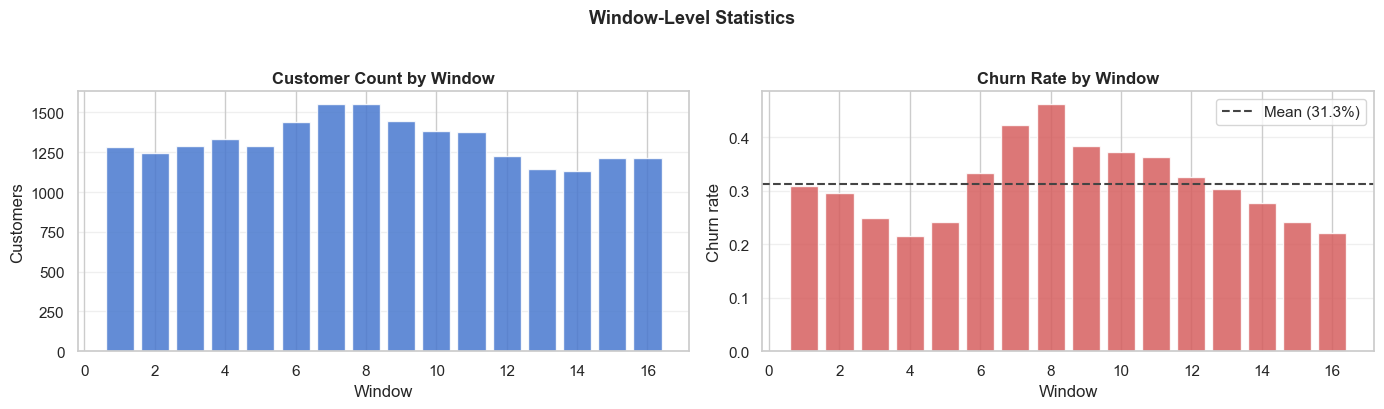

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Customer count per window
axes[0].bar(
    stats_df["window"],
    stats_df["customers"],
    color="#4878CF",
    alpha=0.85,
    edgecolor="white",
)
axes[0].set_xlabel("Window")
axes[0].set_ylabel("Customers")
axes[0].set_title("Customer Count by Window", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Churn rate per window with mean baseline
mean_churn = stats_df["churn_rate"].mean()

axes[1].bar(
    stats_df["window"],
    stats_df["churn_rate"],
    color="#D65F5F",
    alpha=0.85,
    edgecolor="white",
)
axes[1].axhline(
    mean_churn,
    linestyle="--",
    linewidth=1.5,
    color="#444444",
    label=f"Mean ({mean_churn:.1%})",
)
axes[1].set_xlabel("Window")
axes[1].set_ylabel("Churn rate")
axes[1].set_title("Churn Rate by Window", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Window-Level Statistics", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/window_statistics.png",
            bbox_inches="tight", dpi=150)
plt.show()

Customer count is stable across windows (~1,100–1,550), confirming the 
sliding window generation produced consistent observations. The churn rate 
varies considerably (from approximately 21% to 46%) driven by seasonal 
purchasing patterns rather than class imbalance. Both classes are well 
represented throughout the dataset.

This seasonal variation has a direct implication for modeling: the 
walk-forward validation folds will see different baseline churn rates, 
which affects the interpretation of lift-based metrics across folds. 
This is addressed in the modeling notebook.

## 6. Feature Stability Analysis

Before handing the dataset to the modeling stage, it is important to verify 
that engineered features remain consistent across temporal windows. Large 
shifts in feature means or distributions could indicate:

- **Temporal drift** — genuine changes in customer behavior over time
- **Pipeline inconsistencies** — bugs in the feature engineering logic 
  that produce different results for different windows

Moderate variation is expected and acceptable. Churn rates vary seasonally, 
so behavioral features will naturally shift with them. What we are looking 
for is the absence of **abrupt discontinuities** that would suggest a 
pipeline problem rather than a real behavioral signal.

Four features are monitored, selected to cover independent behavioral 
dimensions: the two most informative RFM signals, the dominant model 
predictor, and a timing feature that captures purchase cadence independently 
of the RFM dimensions.

In [12]:
key_features = [
    "Recency",               # RFM - time dimension
    "Monetary",              # RFM - value dimension
    "ValueEngagement",       # dominant model predictor - joint value and engagement
    "AvgPurchaseInterval",   # timing - purchase cadence, independent of RFM
]

# These four cover independent behavioral dimensions:
# - Recency and AvgPurchaseInterval capture the time/cadence axis from
#   complementary angles (how long since last purchase vs typical gap)
# - Monetary captures the value axis independently of engagement
# - ValueEngagement is monitored specifically because it is the strongest
#   model predictor, confirming its stability is more important than
#   monitoring a redundant feature like Frequency or EngagementDensity,
#   which are highly correlated with it by construction
missing_features = [f for f in key_features if f not in final_dataset.columns]
assert not missing_features, f"Missing expected features: {missing_features}"

window_means = final_dataset.groupby("WindowID")[key_features].mean()

### 6.1 Mean stability

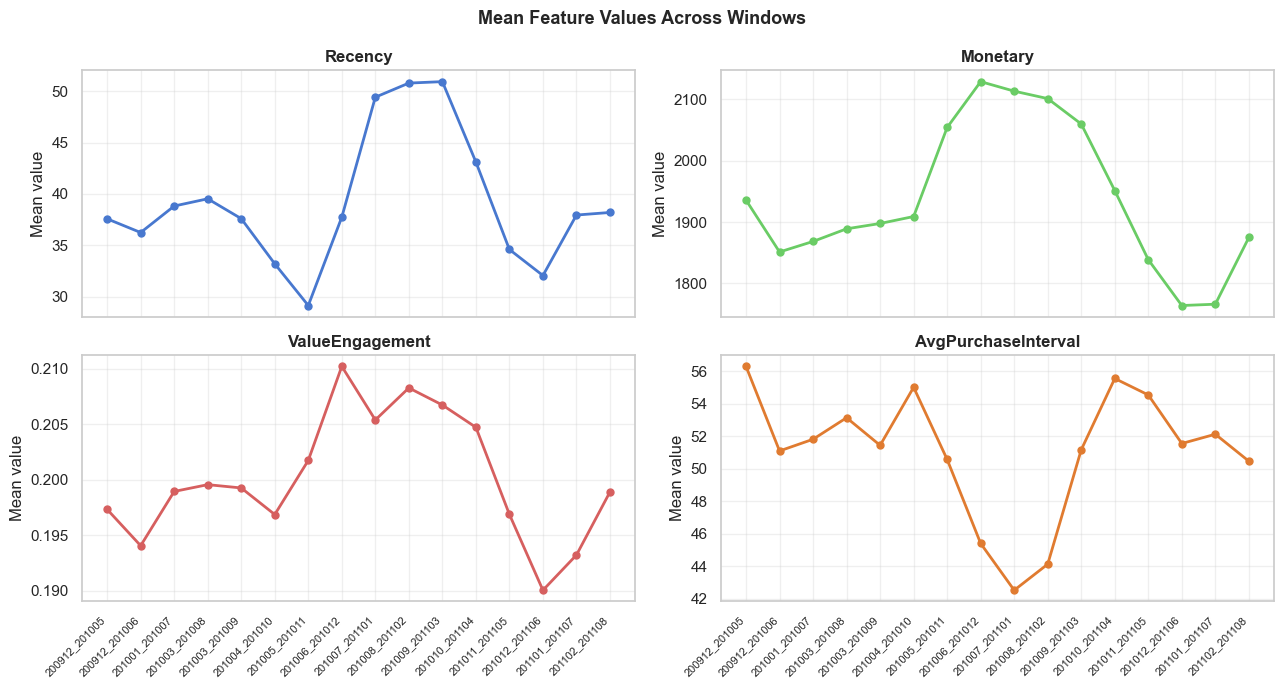

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
axes = axes.flatten()

colors = ["#4878CF", "#6ACC65", "#D65F5F", "#E07B30"]

for i, (feature, color) in enumerate(zip(key_features, colors)):
    axes[i].plot(
        range(len(window_means)),
        window_means[feature],
        marker="o",
        linewidth=2,
        color=color,
        markersize=5,
    )
    axes[i].set_title(feature, fontweight="bold")
    axes[i].set_ylabel("Mean value")
    axes[i].grid(alpha=0.3)

    if i >= 2:
        axes[i].set_xticks(range(len(window_means)))
        axes[i].set_xticklabels(
            window_means.index,
            rotation=45,
            ha="right",
            fontsize=8,
        )

plt.suptitle("Mean Feature Values Across Windows", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/feature_mean_stability.png",
            bbox_inches="tight", dpi=150)
plt.show()

The four features show distinct temporal patterns, confirming they capture 
independent behavioral dimensions rather than the same underlying signal.

`Recency` shows the strongest seasonal variation: dropping sharply to 
~29 days around mid/end-2010 when customers were most recently active, then 
rising to a peak of ~51 days in early 2011 before returning to baseline. 
This reflects genuine seasonal purchasing behavior rather than a pipeline 
artifact.

`Monetary` follows a clear arc: rising steadily through the middle 
windows to a peak of ~£2,120, then dropping noticeably in the final 
three windows to approximately £1,775. This decline in the test period 
windows is consistent with the lower churn rate observed in the test 
set. A period of lower spending coincides with a different customer 
behavioral profile than the training windows.

`ValueEngagement` broadly mirrors `Monetary`: rising through the 
mid-dataset and declining at the end, with more window-to-window 
noise. Despite this variation the range is narrow (0.190–0.210), 
and the trend is smooth with no discontinuities. Given its dominance 
as the strongest model predictor, the absence of structural breaks 
here is an important confirmation of pipeline stability.

`AvgPurchaseInterval` shows the most distinct pattern of the four. 
It starts high (~56 days), drops sharply to ~42 days around mid/end-2010.
The same period where `Recency` also dips, confirming a genuine 
spike in customer purchasing activity, then gradually recovers 
toward the end. This inverse relationship with `Recency` is 
mechanically expected and validates both features are measuring 
the same seasonal phenomenon from complementary angles.

All four features show smooth trends with no abrupt discontinuities, 
confirming the pipeline produces consistent output across time. The 
variation present reflects genuine seasonal customer behavior and is 
accounted for by the walk-forward validation strategy in the modeling 
stage.

### 6.2 Distribution stability

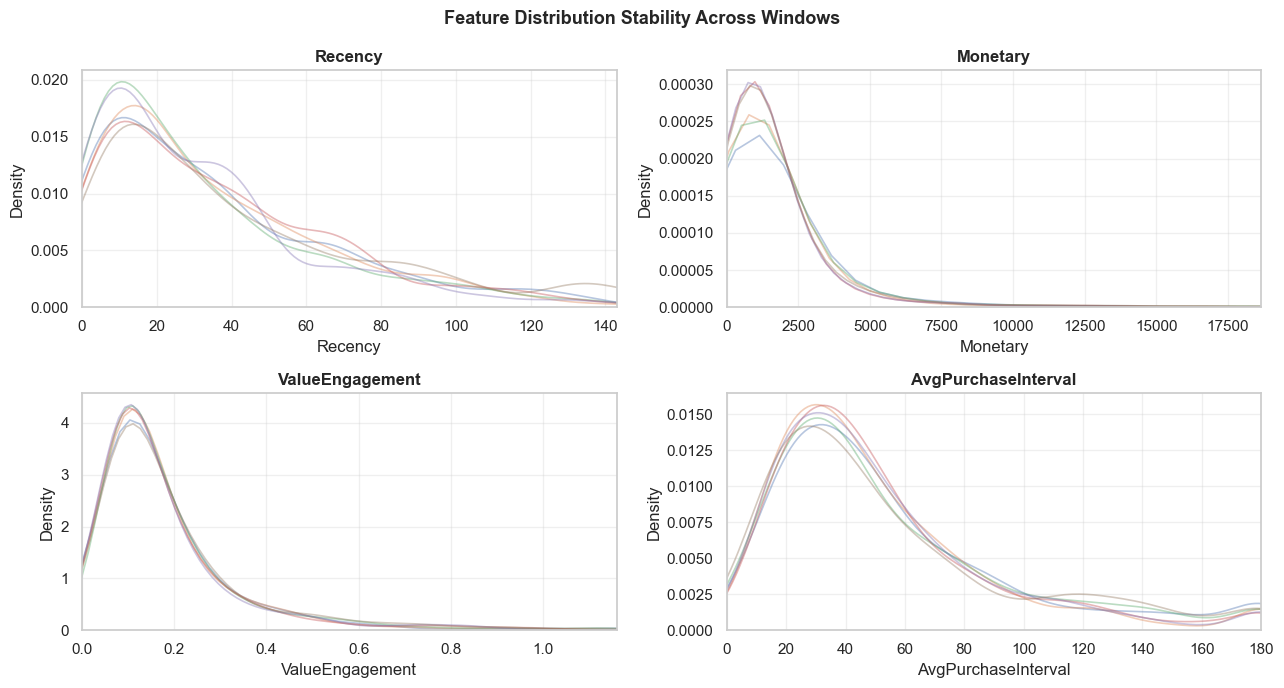

In [14]:
sample_windows = (
    final_dataset["WindowID"]
    .drop_duplicates()
    .sample(min(6, final_dataset["WindowID"].nunique()), random_state=RANDOM_STATE)
    .values
)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    for w in sample_windows:
        sns.kdeplot(
            data=final_dataset.loc[final_dataset["WindowID"] == w, feature],
            ax=axes[i],
            alpha=0.4,
            linewidth=1.2,
        )

    xmax = final_dataset[feature].quantile(0.99)
    axes[i].set_xlim(0, xmax)
    axes[i].set_title(feature, fontweight="bold")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")
    axes[i].grid(alpha=0.3)

plt.suptitle("Feature Distribution Stability Across Windows",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/feature_distribution_stability.png",
            bbox_inches="tight", dpi=150)
plt.show()

The distribution plots confirm the stability suggested by the mean trends, 
with all four features showing consistent shapes across the six sampled 
windows and no abrupt structural changes.

`ValueEngagement` is the most stable. Curves are nearly indistinguishable 
across windows, confirming the dominant model predictor captures a 
consistent behavioral signal throughout the dataset.

`Monetary` maintains a consistent right-skewed shape across windows, 
but the peak density varies noticeably (ranging from ~0.000230 to 
~0.000300) reflecting the seasonal shift in how concentrated customers 
are around typical spending levels. This is consistent with the mean 
stability analysis which showed Monetary rising and falling across 
windows rather than holding flat.

`AvgPurchaseInterval` shows uniform variation across the full 
distribution. The curves shift up and down by a similar magnitude 
at both the peak and in the tail, rather than diverging only at the 
extremes. This reflects windows where customers collectively purchase 
more or less frequently, shifting the entire cadence distribution 
rather than just affecting outliers.

`Recency` shows the most distributional variation, consistent with 
the mean stability analysis. Both the peak height and the right tail 
spread across windows as the proportion of recently inactive customers 
shifts with seasonal purchasing patterns. The core shape remains 
recognizable across all windows, confirming this is behavioral 
variation rather than a structural pipeline change.

Overall the distribution shapes are sufficiently stable to support 
walk-forward modeling. The pipeline is not producing structurally 
different feature sets in different windows.

## 7. Feature-Target Relationships

To understand which behavioral features carry the strongest predictive 
signal for churn, we examine the linear correlation between each feature 
and the target variable `IsChurned`.

Correlation is a limited measure. It only captures linear relationships 
and says nothing about interaction effects or non-linear patterns. It is 
used here purely as a quick directional check to verify the engineered 
features align with domain expectations before handing the dataset to 
the model.

Two directions are expected from theory:

- **Negative correlation** — higher values associated with lower churn 
  risk: frequency, monetary spend, engagement metrics
- **Positive correlation** — higher values associated with higher churn 
  risk: recency, purchase interval, delay ratio

In [15]:
correlations = (
    final_dataset[feature_cols + ["IsChurned"]]
    .corr()["IsChurned"]
    .drop("IsChurned")
    .sort_values()
)

In [16]:
top_corr_abs = correlations.reindex(
    correlations.abs().sort_values(ascending=False).head(10).index
)

print("Top 10 features by absolute correlation with IsChurned")
print("=" * 55)
print(f"  {'Feature':<25} {'Correlation':>11}  Direction")
print(f"  {'-'*25} {'-'*11}  {'-'*9}")
for feat, val in top_corr_abs.items():
    direction = "↑ higher risk" if val > 0 else "↓ lower risk"
    print(f"  {feat:<25} {val:>+11.3f}  {direction}")

Top 10 features by absolute correlation with IsChurned
  Feature                   Correlation  Direction
  ------------------------- -----------  ---------
  LogMonetary                    -0.282  ↓ lower risk
  EngagementDensity              -0.243  ↓ lower risk
  ValueEngagement                -0.235  ↓ lower risk
  AvgPurchaseInterval            +0.223  ↑ higher risk
  Frequency                      -0.214  ↓ lower risk
  Recency                        +0.211  ↑ higher risk
  UniqueProducts                 -0.176  ↓ lower risk
  PurchaseIntervalCV             -0.148  ↓ lower risk
  Q4Ratio                        +0.130  ↑ higher risk
  Monetary                       -0.129  ↓ lower risk


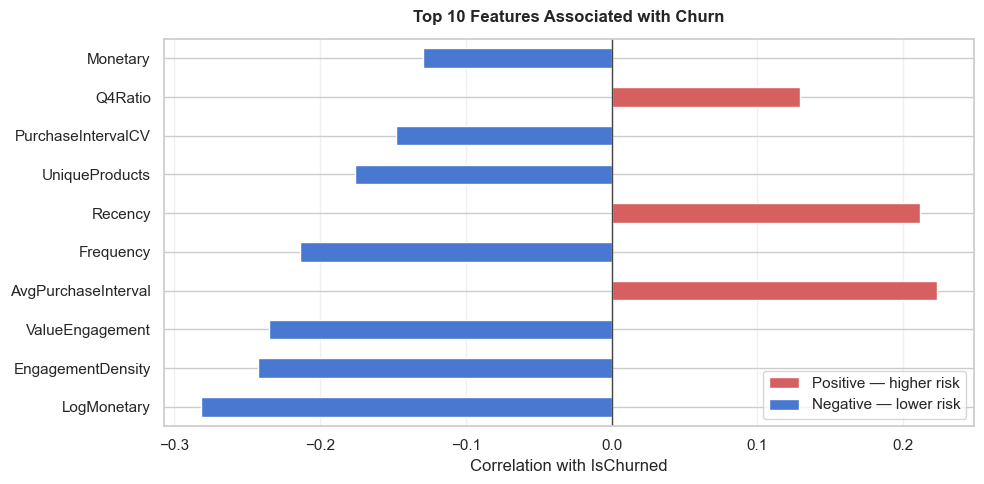

In [17]:
colors = ["#D65F5F" if v > 0 else "#4878CF" for v in top_corr_abs]

fig, ax = plt.subplots(figsize=(10, 5))
top_corr_abs.plot(kind="barh", color=colors, ax=ax, edgecolor="white")

ax.axvline(0, color="#444444", linewidth=1)
ax.set_xlabel("Correlation with IsChurned")
ax.set_title("Top 10 Features Associated with Churn",
             fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.3)

# Legend
legend_elements = [
    Patch(facecolor="#D65F5F", label="Positive — higher risk"),
    Patch(facecolor="#4878CF", label="Negative — lower risk"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("../reports/figures/feature_target_correlations.png",
            bbox_inches="tight", dpi=150)
plt.show()

### 7.1 Interpretation

The correlation pattern aligns with domain expectations across all 
behavioral dimensions.

**Value and engagement features dominate the negative end.** 
`LogMonetary` (-0.282) and `EngagementDensity` (-0.243) are the two 
strongest individual correlate. Customers with higher spend and 
denser activity are significantly less likely to churn. `ValueEngagement` 
(-0.235) sits just below them, which is expected since it is derived 
from their product. `Frequency` (-0.214) and `UniqueProducts` (-0.176) 
follow the same pattern, more engaged customers across multiple 
dimensions are less likely to leave.

Interestingly, raw `Monetary` (-0.129) ranks lower than `LogMonetary` 
(-0.282), confirming that the log transformation better captures the 
relationship between spend and churn. The signal is stronger in 
relative spending differences than in absolute amounts.

**Timing features dominate the positive end.** `AvgPurchaseInterval` 
(+0.223) and `Recency` (+0.211) are the strongest positive correlates. 
Customers with longer gaps between purchases and longer time since 
their last purchase are at higher churn risk. `PurchaseIntervalCV` 
(-0.148) shows a negative correlation, suggesting that customers with 
more variable purchase intervals are slightly less likely to churn.
This is counterintuitive and may reflect occasional bulk buyers whose 
irregular cadence does not indicate disengagement.

**`Q4Ratio`** (+0.130) appears in the top 10 with a positive 
correlation, but as shown in section 8.2 this signal is only present 
in windows overlapping Q4. It is a calendar artifact rather than a 
genuine behavioral predictor and should be interpreted with caution.

Note that all correlations are modest (0.13–0.28) — this is expected 
for behavioral churn prediction where no single feature is 
deterministic and the model derives power from combining multiple 
weak signals across non-linear interactions that linear correlation 
cannot capture.

## 8. Conclusions and Known Issues

### 8.1 Summary

This notebook constructed a customer-level modeling dataset for churn 
prediction using a sliding temporal window approach. Starting from 
transactional purchase data for UK customers, 23 behavioral features 
were engineered across eight groups: RFM, order value, returns, 
engagement intensity, early lifecycle, seasonality, trend signals, 
timing, product behavior, and a derived interaction feature.

The pipeline produces one observation per customer per window 
(21,110 rows across 16 windows) with no missing or infinite values 
in the final feature set. Temporal stability analysis confirmed 
that feature distributions remain consistent across windows, with 
variation reflecting genuine seasonal behavior rather than pipeline 
inconsistencies.

Key findings from feature design and validation:

- **`ValueEngagement`** (LogMonetary × EngagementDensity) combines 
  two of the strongest individual correlates (`LogMonetary` at -0.282 
  and `EngagementDensity` at -0.243) into a single interaction term,
  later confirmed as the dominant predictor by SHAP analysis in the 
  modeling notebook, where it outperformed both components individually
- **Early lifecycle features** improve identification of early-churn customers who would otherwise look similar to 
  low-frequency regulars
- **Trend features** (`RevenueTrend`, `RecentShareLog`) were 
  retained after iterative performance evaluation during modeling
- **Timing consistency** (`PurchaseIntervalCV`, `DelayRatio`) 
  correlates positively with churn, suggesting irregular purchase 
  cadence is an early disengagement signal
- **Churn rate varies seasonally** (21%–46% across windows)
  This is not class imbalance but genuine behavioral variation 
  that the walk-forward validation strategy in the modeling 
  notebook accounts for

### 8.2 Known issues and next iteration

**`Q4Ratio` should be removed.** It is zero for all customers in 
windows that do not overlap October–December, including both test 
windows and two training windows. It is a calendar artifact rather 
than a behavioral signal. Despite appearing as the second most 
important feature in the SHAP analysis, its contribution is 
structurally meaningless outside Q4 observation periods.

A rolling seasonal activity feature would be a suitable replacement.
For example, the ratio of purchases in a customer's historically 
active months relative to their overall frequency. This would remain 
meaningful year-round and capture genuine seasonal purchasing habits 
rather than a calendar overlap artifact.

In [18]:
# Verify Q4Ratio is zero outside Q4 observation windows
q4_by_window = final_dataset.groupby("WindowID")["Q4Ratio"].agg(["mean", "max"])
nonzero_windows = (q4_by_window["max"] > 0).sum()
total_windows   = len(q4_by_window)

print(f"Windows where Q4Ratio has signal:  {nonzero_windows}/{total_windows}")
print(f"Windows where Q4Ratio = 0:         {total_windows - nonzero_windows}/{total_windows}")
print()
print("Q4Ratio is a calendar artifact — zero in all windows outside Q4.")
print("Recommendation: remove and replace with a rolling seasonal feature.")

Windows where Q4Ratio has signal:  9/16
Windows where Q4Ratio = 0:         7/16

Q4Ratio is a calendar artifact — zero in all windows outside Q4.
Recommendation: remove and replace with a rolling seasonal feature.


**Cross-window lag features are not included.** Features are computed 
independently per window, so the model cannot detect behavioral 
trajectory. A customer dropping from 10 purchases to 3 looks 
identical to one who has always purchased 3 times. Delta features 
capturing change from the previous window would directly encode 
disengagement trends and are the highest-priority addition for the 
next iteration.

**Feature importance was checked at one point during development**, 
not systematically throughout. Three features (`LogFrequency`, 
`IsOrderValueCVDefined`, `IsPurchaseIntervalCVDefined`) were removed 
after an importance inspection, but other removed features were 
dropped based on model performance observation rather than formal 
analysis. A structured ablation study would give a more rigorous 
account of each feature's contribution.

In [19]:
output_path = "../data/processed/churn_features_sliding_window.parquet"
final_dataset.to_parquet(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print()
print(f"  Rows:       {len(final_dataset):,}")
print(f"  Columns:    {final_dataset.shape[1]}")
print(f"  Features:   {len(feature_cols)}")
print(f"  Windows:    {final_dataset['WindowID'].nunique()}")
print(f"  Customers:  {final_dataset['CustomerID'].nunique():,}")
print(f"  Churn rate: {final_dataset['IsChurned'].mean():.1%}")

Dataset saved to: ../data/processed/churn_features_sliding_window.parquet

  Rows:       21,110
  Columns:    28
  Features:   23
  Windows:    16
  Customers:  2,775
  Churn rate: 31.8%
